In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import copy
import math
from collections import OrderedDict, Counter
import os,time
import itertools
import matplotlib.pyplot as plt
#import hypernetx as hnx
import json

In [2]:
beta = 0.04
r = 0.1 #重连指数函数的基底
v = 3  #非线性传播指数
h = 4.8 #非线性重连指数
m = 3 # 超边大小
mu = 0.2 #恢复概率
lam = 1 # 连接S的偏好或准确程度
#beta_list=[0.001*i for i in range(51)]

In [3]:
# 导入真实超图数据
_Data_PATH_XX_ = './network_data/new_aug_network_10_27/'
_Figure_PATH_XX_ = './figures/real_network/'
_Simulation_results = './simulation_results/real_network/'

In [4]:
#导入网络数据
datasetlist = ['InVS15n=5','LyonSchooln=5','Thiers13n=5']
dataset = datasetlist[2]
#选取其中一个案例
edge_list = json.load(open(_Data_PATH_XX_+dataset+'.json'))[0]
print(len(edge_list))
#节点规模
N = max([max(i) for i in edge_list]) + 1
print(N)
#区分2，3连边集合
pair_set = set()
hyper_set = set()
for i in edge_list:
    if len(i) == 2:
        pair_set.add(tuple(i))
    else:
        hyper_set.add(tuple(i))

print(len(pair_set))
print(len(hyper_set))

8410
1621
3570
4840


In [5]:
#仿真数据导入
n0_list = [0.03,0.9]
average_results = {}
average_minus_std = {}
average_add_std = {}
suscepbility_phase = {}
for n0 in n0_list:
    filename = dataset+ '_v'+ str(v) + '_r' + str(r) + '_h' + str(h) + '_p' +str(lam) +'_mu'+str(mu)+'n0'+str(n0)
    rho_dict = np.load(_Simulation_results + filename + '.npy',allow_pickle=True).item()
    #print(rho_dict)
    average_results[n0]=[]
    average_minus_std[n0] =[]
    average_add_std[n0] = []
    suscepbility_phase[n0] = []
    beta_list = []
    for key, value in rho_dict.items():
        tem = np.mean(value)/N
        std_value = np.std(value)/N
        average_results[n0].append(tem)
        average_minus_std[n0].append(tem-std_value)
        average_add_std[n0].append(tem+std_value)
        value_squ = [x**2 for x in value]
        ave_squ = np.mean(value_squ)
        ave_val = np.mean(value)
        if ave_squ == 0:
            suscepbility_phase[n0].append(0)
        else:
            suscepbility_phase[n0].append((ave_squ-ave_val**2)/ave_val)
        beta_list.append(key)

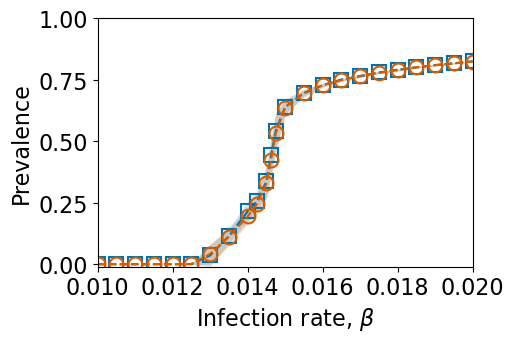

In [7]:
#画图
#color_map=['#ff7f0e','#436EEE']
color_map=['#0072B2', '#D55E00', '#009E73', '#E69F00']
marker_shape = ['o','d','s','d']
plt.figure(figsize=(5,3.5))
plt.plot(beta_list, average_results[n0_list[0]],'--s',color=color_map[0],markersize=10,markerfacecolor='none',markeredgewidth=1.5,label="$\\rho_0$="+str(n0_list[0]))
plt.plot(beta_list, average_results[n0_list[1]],'--o',color=color_map[1],markersize=10,markerfacecolor='none',markeredgewidth=1.5,label="$\\rho_0$="+str(n0_list[1]))

plt.fill_between(beta_list, average_add_std[n0_list[0]], average_minus_std[n0_list[0]],color=color_map[0], linewidth = 0, alpha=0.2)
plt.fill_between(beta_list, average_add_std[n0_list[1]], average_minus_std[n0_list[1]],color=color_map[1], linewidth = 0, alpha=0.2)
font1 = {'weight': 'normal','size':16}
font2 = {'weight': 'normal','size':16}
plt.ylim((-0.01,1))
#plt.xlim((0.005,0.015))
#plt.xticks([0.005,0.007,0.009,0.011,0.013,0.015],['0.005','0.007','0.009','0.011','0.013','0.015'])
#plt.xlim((0.005,0.025))
#plt.xlim((0.01,0.03))
plt.xlim((0.01,0.02))
#plt.xlim((0.0,0.01))
#plt.xlim((0.0,0.02))
#plt.xlim((0.005,0.01))
#plt.xlim((0.0,0.03))
#plt.xlim((0.01,0.04))
#plt.xlim((0.007,0.017))
#plt.xticks([0.007,0.009,0.011,0.013,0.015,0.017],['0.007','0.009','0.011','0.013','0.015','0.0017'])
plt.subplots_adjust(left=0.19,bottom=0.17,right=0.94)
plt.tick_params(labelsize=16)
plt.xlabel('Infection rate, $\\beta$',font1)
plt.ylabel('Prevalence',font1)
#plt.legend(prop=font2)
#plt.fill_between(time, data_min-std, data_max, color='violet', alpha=0.2)
#plt.legend()
#plt.show()
plt.savefig(_Figure_PATH_XX_ + filename + '.png', dpi = 400)
plt.show()